In [2]:
import numpy as np
import matplotlib.pyplot as plt
import cv2
import os

from sklearn.cluster import KMeans

!pip install scikit-fuzzy

import skfuzzy as fuzz

from sklearn.metrics import jaccard_score

plt.rcParams['figure.figsize'] = (6,6)
plt.rcParams['image.cmap'] = 'gray'

print("Libraries imported successfully.")


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 920.8/920.8 kB 19.0 MB/s eta 0:00:00
Libraries imported successfully.


In [3]:
import kagglehub
import os

dataset_path = kagglehub.dataset_download("paultimothymooney/blood-cells")

print("Dataset downloaded to:", dataset_path)


100%|██████████| 108M/108M [00:01<00:00, 83.0MB/s]

Extracting files...


Dataset downloaded to: /root/.cache/kagglehub/datasets/paultimothymooney/blood-cells/versions/6


Total images in NEUTROPHIL: 2499
Selected image: /root/.cache/kagglehub/datasets/paultimothymooney/blood-cells/versions/6/dataset2-master/dataset2-master/images/TRAIN/NEUTROPHIL/_0_1095.jpeg


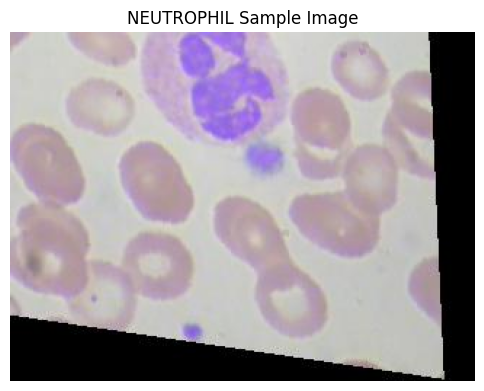

In [4]:
train_path = os.path.join(dataset_path, "dataset2-master", "dataset2-master", "images", "TRAIN")

wbc_class = "NEUTROPHIL"

class_path = os.path.join(train_path, wbc_class)

image_files = os.listdir(class_path)

print(f"Total images in {wbc_class}:", len(image_files))

image_name = image_files[0]

image_path = os.path.join(class_path, image_name)

print("Selected image:", image_path)

image = cv2.imread(image_path)

image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

plt.imshow(image_rgb)
plt.title(f"{wbc_class} Sample Image")
plt.axis('off')
plt.show()


In [5]:
h, w, c = image_rgb.shape

print("Image shape:", image_rgb.shape)
print("Height:", h, "Width:", w, "Channels:", c)


pixel_values = image_rgb.reshape((-1, 3))


pixel_values = np.float32(pixel_values)

print("Feature matrix shape:", pixel_values.shape)


Image shape: (240, 320, 3)
Height: 240 Width: 320 Channels: 3
Feature matrix shape: (76800, 3)


In [6]:
k = 3

kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)

kmeans_labels = kmeans.fit_predict(pixel_values)

print("K-Means clustering completed.")

centers = kmeans.cluster_centers_

print("Cluster centers:")
print(centers)


K-Means clustering completed.
Cluster centers:
[[178.819      155.76642    178.33176   ]
 [  0.68548584   0.5496063    0.6469116 ]
 [201.165      197.38562    197.06854   ]]


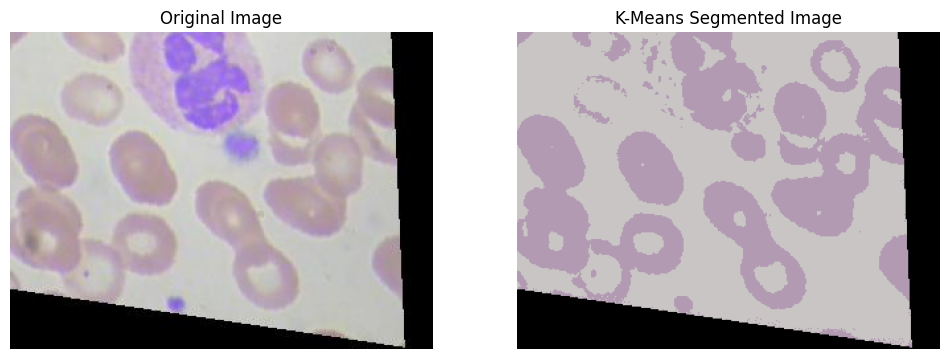

In [7]:
segmented_pixels = centers[kmeans_labels]
segmented_pixels = np.uint8(segmented_pixels)
segmented_image_kmeans = segmented_pixels.reshape(image_rgb.shape)
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.imshow(image_rgb)
plt.title("Original Image")
plt.axis('off')
plt.subplot(1,2,2)
plt.imshow(segmented_image_kmeans)
plt.title("K-Means Segmented Image")
plt.axis('off')
plt.show()

In [8]:
threshold = 15
non_black_mask = np.any(image_rgb > threshold, axis=2)
pixel_values_filtered = image_rgb[non_black_mask]
pixel_values_filtered = pixel_values_filtered.reshape(-1,3)
print("Original pixels:", pixel_values.shape)
print("Filtered pixels:", pixel_values_filtered.shape)


Original pixels: (76800, 3)
Filtered pixels: (63590, 3)


In [9]:
k = 3
kmeans_filtered = KMeans(n_clusters=k, random_state=42, n_init=10)
filtered_labels = kmeans_filtered.fit_predict(pixel_values_filtered)
filtered_centers = kmeans_filtered.cluster_centers_
print("K-Means applied on filtered pixels.")

K-Means applied on filtered pixels.


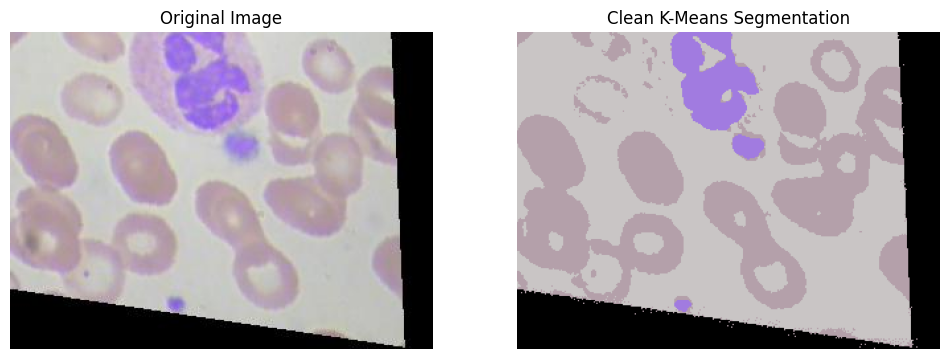

In [10]:
full_labels = np.full((h, w), -1)
full_labels[non_black_mask] = filtered_labels
segmented_image_clean = np.zeros((h, w, 3), dtype=np.uint8)
segmented_image_clean[non_black_mask] = filtered_centers[filtered_labels]
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.imshow(image_rgb)
plt.title("Original Image")
plt.axis('off')
plt.subplot(1,2,2)
plt.imshow(segmented_image_clean)
plt.title("Clean K-Means Segmentation")
plt.axis('off')
plt.show()


In [11]:
data = pixel_values_filtered.T
n_clusters = 3
cntr, u, u0, d, jm, p, fpc = fuzz.cluster.cmeans(
    data,
    c=n_clusters,
    m=2,              # fuzziness parameter
    error=0.005,
    maxiter=1000,
    init=None
)

print("Fuzzy C-Means completed.")

print("Cluster centers:")
print(cntr)

print("FPC (Fuzzy Partition Coefficient):", fpc)


Fuzzy C-Means completed.
Cluster centers:
[[202.41856231 200.6840129  198.15416246]
 [187.60002636 169.08868565 192.03723969]
 [178.61043099 156.07898658 168.81462367]]
FPC (Fuzzy Partition Coefficient): 0.7001630489924574


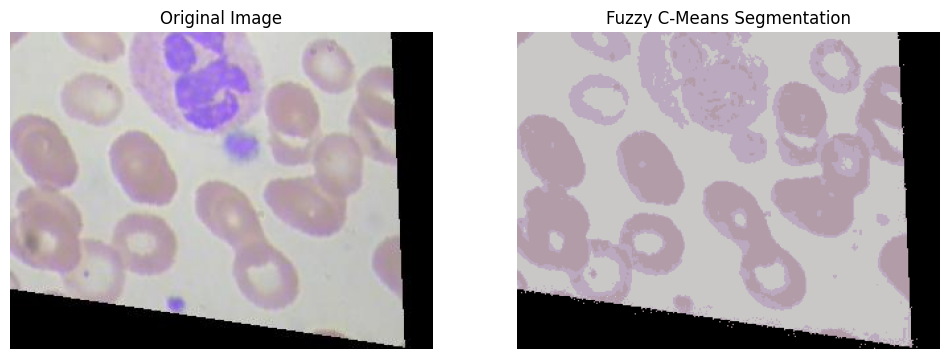

In [12]:
fcm_labels = np.argmax(u, axis=0)
full_fcm_labels = np.full((h, w), -1)
full_fcm_labels[non_black_mask] = fcm_labels
segmented_image_fcm = np.zeros((h, w, 3), dtype=np.uint8)
segmented_image_fcm[non_black_mask] = cntr[fcm_labels]
segmented_image_fcm = np.uint8(segmented_image_fcm)
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.imshow(image_rgb)
plt.title("Original Image")
plt.axis('off')
plt.subplot(1,2,2)
plt.imshow(segmented_image_fcm)
plt.title("Fuzzy C-Means Segmentation")
plt.axis('off')
plt.show()


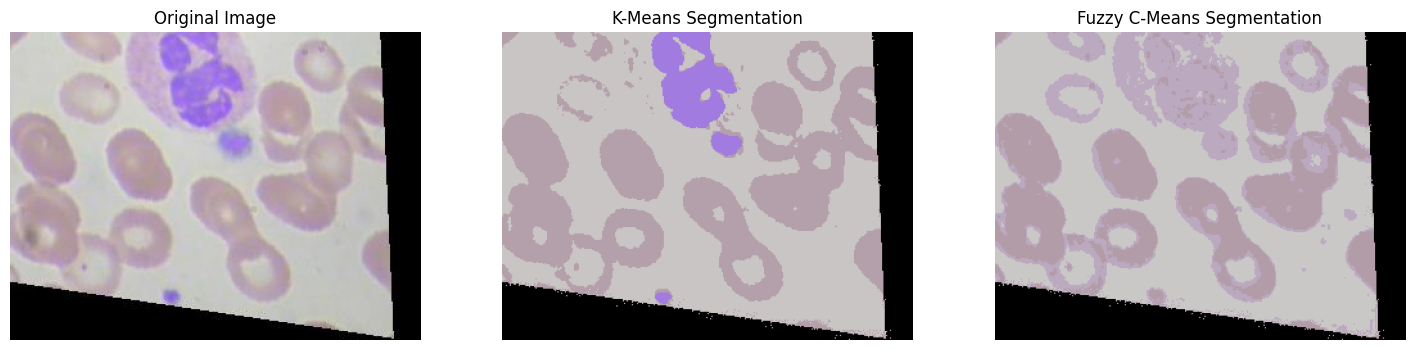

In [13]:
plt.figure(figsize=(18,6))
plt.subplot(1,3,1)
plt.imshow(image_rgb)
plt.title("Original Image")
plt.axis('off')
plt.subplot(1,3,2)
plt.imshow(segmented_image_clean)
plt.title("K-Means Segmentation")
plt.axis('off')
plt.subplot(1,3,3)
plt.imshow(segmented_image_fcm)
plt.title("Fuzzy C-Means Segmentation")
plt.axis('off')
plt.show()


In [14]:
kmeans_brightness = np.sum(filtered_centers, axis=1)
kmeans_nucleus_cluster = np.argmin(kmeans_brightness)
print("K-Means nucleus cluster:", kmeans_nucleus_cluster)


K-Means nucleus cluster: 2


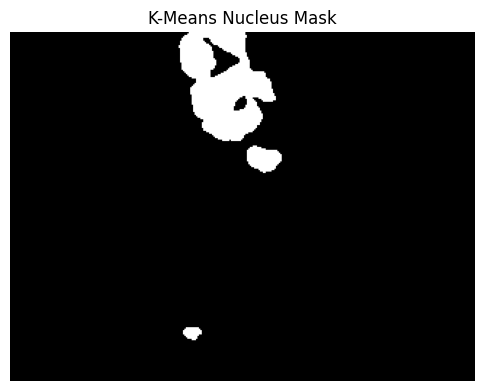

In [15]:
kmeans_nucleus_mask = (full_labels == kmeans_nucleus_cluster)
plt.imshow(kmeans_nucleus_mask, cmap='gray')
plt.title("K-Means Nucleus Mask")
plt.axis('off')
plt.show()


In [16]:
fcm_brightness = np.sum(cntr, axis=1)
fcm_nucleus_cluster = np.argmin(fcm_brightness)
print("FCM nucleus cluster:", fcm_nucleus_cluster)

FCM nucleus cluster: 2


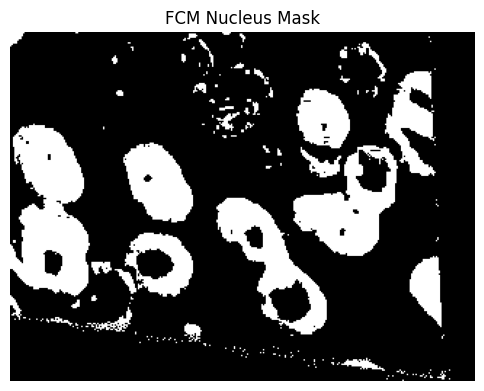

In [17]:
fcm_nucleus_mask = (full_fcm_labels == fcm_nucleus_cluster)
plt.imshow(fcm_nucleus_mask, cmap='gray')
plt.title("FCM Nucleus Mask")
plt.axis('off')
plt.show()


Improved K-Means nucleus cluster: 2


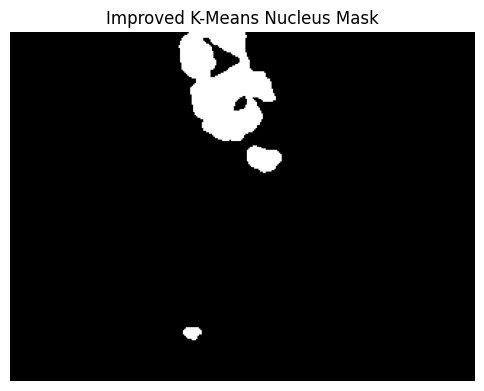

In [18]:
kmeans_purple_score = filtered_centers[:, 2] - filtered_centers[:, 1]
kmeans_nucleus_cluster = np.argmax(kmeans_purple_score)
print("Improved K-Means nucleus cluster:", kmeans_nucleus_cluster)
kmeans_nucleus_mask = (full_labels == kmeans_nucleus_cluster)
plt.imshow(kmeans_nucleus_mask, cmap='gray')
plt.title("Improved K-Means Nucleus Mask")
plt.axis('off')
plt.show()


Improved FCM nucleus cluster: 1


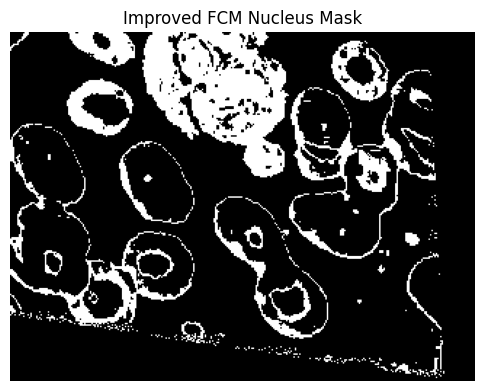

In [19]:
fcm_purple_score = cntr[:, 2] - cntr[:, 1]
fcm_nucleus_cluster = np.argmax(fcm_purple_score)
print("Improved FCM nucleus cluster:", fcm_nucleus_cluster)
fcm_nucleus_mask = (full_fcm_labels == fcm_nucleus_cluster)
plt.imshow(fcm_nucleus_mask, cmap='gray')
plt.title("Improved FCM Nucleus Mask")
plt.axis('off')
plt.show()


In [20]:
kmeans_flat = kmeans_nucleus_mask.flatten().astype(int)
fcm_flat = fcm_nucleus_mask.flatten().astype(int)

def dice_score(mask1, mask2):
    intersection = np.sum(mask1 * mask2)
    return (2.0 * intersection) / (np.sum(mask1) + np.sum(mask2) + 1e-8)

dice = dice_score(kmeans_flat, fcm_flat)
jaccard = jaccard_score(fcm_flat, kmeans_flat)

print("Dice Score (K-Means vs FCM):", dice)
print("Jaccard Index (K-Means vs FCM):", jaccard)


Dice Score (K-Means vs FCM): 0.34441612604243255
Jaccard Index (K-Means vs FCM): 0.2080330277797215


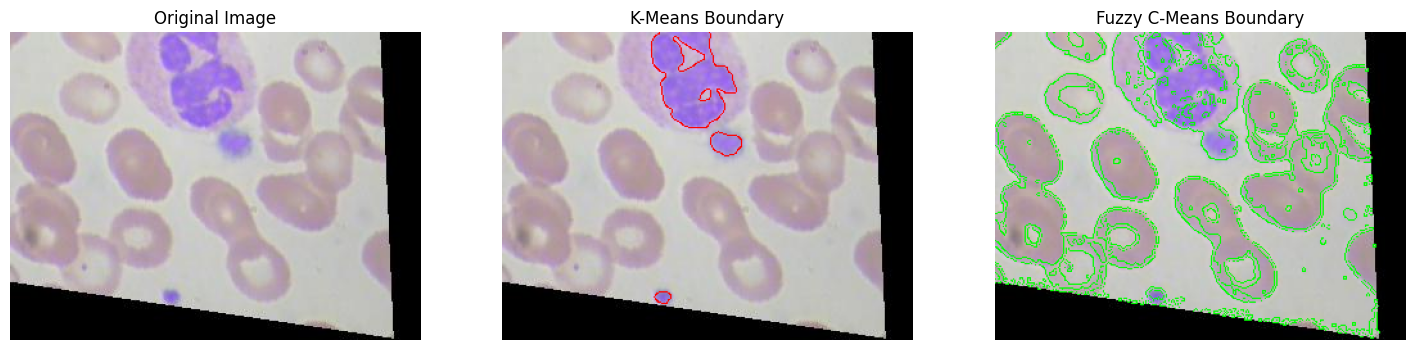

In [21]:
import cv2
kmeans_mask_uint8 = np.uint8(kmeans_nucleus_mask * 255)
fcm_mask_uint8 = np.uint8(fcm_nucleus_mask * 255)
kmeans_edges = cv2.Canny(kmeans_mask_uint8, 50, 150)
fcm_edges = cv2.Canny(fcm_mask_uint8, 50, 150)
overlay_kmeans = image_rgb.copy()
overlay_fcm = image_rgb.copy()
overlay_kmeans[kmeans_edges > 0] = [255, 0, 0]
overlay_fcm[fcm_edges > 0] = [0, 255, 0]
plt.figure(figsize=(18,6))
plt.subplot(1,3,1)
plt.imshow(image_rgb)
plt.title("Original Image")
plt.axis('off')
plt.subplot(1,3,2)
plt.imshow(overlay_kmeans)
plt.title("K-Means Boundary")
plt.axis('off')
plt.subplot(1,3,3)
plt.imshow(overlay_fcm)
plt.title("Fuzzy C-Means Boundary")
plt.axis('off')
plt.show()


## Conclusion

In this project, White Blood Cell (WBC) segmentation was performed using K-Means and Fuzzy C-Means (FCM) clustering. K-Means, a hard clustering method, is faster and simpler but produced less smooth boundaries and sometimes included unwanted regions. FCM, a soft clustering technique, provided smoother and more accurate segmentation by allowing partial pixel membership.

The quantitative evaluation shows a Dice Score of 0.344 and a Jaccard Index of 0.208, indicating low to moderate overlap between the two methods. This suggests noticeable differences in segmentation results, with FCM producing more refined boundaries.

Overall, FCM demonstrates better segmentation quality for medical imaging tasks, while K-Means remains useful due to its simplicity and lower computational cost.